# seleccion_modelo

Proyecto ARIMA / SARIMA / ARIMAX / SARIMAX
Modelación epidemiológica con variables meteorológicas.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PowerTransformer, StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# 1. CARGA DE BASE DE DATOS ORIGINAL
# ============================================================
ruta_excel = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_semanal_meteo_epi.xlsx"
df_orig = pd.read_excel(ruta_excel)
df_orig['fecha'] = pd.to_datetime(df_orig['fecha'])
df_orig.set_index('fecha', inplace=True)

df_transf = df_orig[['año', 'semana_epi']].copy()

In [4]:
# ============================================================
# 2. APLICACIÓN DE LAS TRANSFORMACIONES
# ============================================================
df_transf['casos_ln'] = np.log1p(df_orig['casos_dengue'])
df_transf['prec_ln'] = np.log1p(df_orig['prec'])
df_transf['dias_lluvia_ln'] = np.log1p(df_orig['dias_lluvia'])

pt_boxcox = PowerTransformer(method='box-cox')
vars_local = ['temp_max', 'hum_esp', 'vel_vi_max']
for var in vars_local:
    datos_var = df_orig[[var]].copy()
    if (datos_var <= 0).any().any():
        datos_var = datos_var - datos_var.min() + 0.01
    df_transf[f'{var}_bc'] = pt_boxcox.fit_transform(datos_var)

pt_yeo = PowerTransformer(method='yeo-johnson')
df_transf['sst_yj'] = pt_yeo.fit_transform(df_orig[['sst']])

In [5]:
# ============================================================
# 3. CONSTRUCCIÓN DE REZAGOS PARA TUS 6 VARIABLES
# ============================================================
tus_6_variables = ['hum_esp_bc', 'prec_ln', 'dias_lluvia_ln', 'vel_vi_max_bc', 'temp_max_bc', 'sst_yj']
max_lag = 20

lags_dict = {}
for lag in range(1, max_lag + 1):
    for var in tus_6_variables:
        lags_dict[f'{var}_lag_{lag}'] = df_transf[var].shift(lag)

df_lags = pd.DataFrame(lags_dict, index=df_transf.index)
df_total = pd.concat([df_transf[['año', 'semana_epi', 'casos_ln']], df_lags], axis=1).dropna()

In [6]:
# ============================================================
# 4. DIVISIÓN CRONOLÓGICA (TRAIN: 2021-2024 vs TEST: 1S-2025)
# ============================================================
df_train_cron = df_total[df_total['año'].isin([2021, 2022, 2023, 2024])]
df_test_cron = df_total[(df_total['año'] == 2025) & (df_total['semana_epi'] <= 26)]

variables_lags_generados = list(lags_dict.keys())
X_train = df_train_cron[variables_lags_generados]
X_test = df_test_cron[variables_lags_generados]

y_train = df_train_cron['casos_ln']
y_test = df_test_cron['casos_ln']

y_train_real = df_orig.loc[df_train_cron.index, 'casos_dengue']
y_test_real = df_orig.loc[df_test_cron.index, 'casos_dengue']

In [7]:
# ============================================================
# 5. ESTANDARIZACIÓN Y FILTRADO CON LASSO
# ============================================================
scaler_X = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_X.fit_transform(X_train), columns=variables_lags_generados, index=y_train.index)
X_test_scaled = pd.DataFrame(scaler_X.transform(X_test), columns=variables_lags_generados, index=y_test.index)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

lasso_model = LassoCV(cv=5, random_state=42).fit(X_train_scaled, y_train_scaled)
coeficientes = pd.Series(lasso_model.coef_, index=variables_lags_generados)
vars_ganadoras_lasso = coeficientes[coeficientes != 0].index.tolist()

if len(vars_ganadoras_lasso) == 0:
    vars_ganadoras_lasso = coeficientes.abs().nlargest(3).index.tolist()

X_train_lasso_sub = X_train_scaled[vars_ganadoras_lasso]
X_test_lasso_sub = X_test_scaled[vars_ganadoras_lasso]

# Función para calcular MAPE de forma segura en Salud Pública (evita división por cero)
def calcular_mape_seguro(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Reemplazar ceros por un valor muy pequeño (0.5 casos) para evitar indeterminación
    y_true_mod = np.where(y_true == 0, 0.5, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true_mod)) * 100

def inversa_total_local(y_scaled_val):
    y_ln_val = scaler_y.inverse_transform(np.array(y_scaled_val).reshape(-1, 1)).flatten()
    return np.expm1(y_ln_val)

todas_las_metricas = []

In [8]:
# ============================================================
# 6. EVALUACIÓN DE LASSO PURO
# ============================================================
pred_lasso_tr = inversa_total_local(lasso_model.predict(X_train_scaled))
pred_lasso_te = inversa_total_local(lasso_model.predict(X_test_scaled))

todas_las_metricas.append({
    'Modelo': 'LASSO_Puro', 'Configuración': f'alpha={lasso_model.alpha_:.4f}',
    'MAE_Train': mean_absolute_error(y_train_real, pred_lasso_tr), 
    'MAE_Test': mean_absolute_error(y_test_real, pred_lasso_te),
    'RMSE_Test': np.sqrt(mean_squared_error(y_test_real, pred_lasso_te)), 
    'MAPE_Test(%)': calcular_mape_seguro(y_test_real, pred_lasso_te),
    'R2_Test': r2_score(y_test_scaled, lasso_model.predict(X_test_scaled)),
    'AIC': np.nan, 'BIC': np.nan, 'Ljung_Box_p': np.nan
})

In [9]:
# ============================================================
# 7. MODELOS BOX-JENKINS CON METRICAS DE DIAGNÓSTICO
# ============================================================
arima_orders = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), (1,1,2), (2,1,2)]
arimax_orders = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), (1,1,2), (2,1,2)]
sarima_orders = [((1,1,1),(1,1,1,52)), ((1,1,0),(1,1,1,52)), ((0,1,1),(1,1,1,52)), ((2,1,1),(1,1,1,52)), ((1,1,2),(1,1,1,52))]
sarimax_orders = [((1,1,1),(1,1,1,52)), ((1,1,0),(1,1,1,52)), ((0,1,1),(1,1,1,52)), ((2,1,1),(1,1,1,52)), ((1,1,2),(1,1,1,52))]

experimentos = [
    {'tipo': 'ARIMA', 'ordenes': [(o, (0,0,0,0)) for o in arima_orders], 'exog_tr': None, 'exog_te': None},
    {'tipo': 'SARIMA', 'ordenes': sarima_orders, 'exog_tr': None, 'exog_te': None},
    {'tipo': 'ARIMAX', 'ordenes': [(o, (0,0,0,0)) for o in arimax_orders], 'exog_tr': X_train_lasso_sub, 'exog_te': X_test_lasso_sub},
    {'tipo': 'SARIMAX', 'ordenes': sarimax_orders, 'exog_tr': X_train_lasso_sub, 'exog_te': X_test_lasso_sub}
]

for exp in experimentos:
    for orden_p, orden_s in exp['ordenes']:
        try:
            model = SARIMAX(endog=y_train, exog=exp['exog_tr'], order=orden_p, seasonal_order=orden_s)
            fitted_model = model.fit(disp=False)
            
            # Predicciones y reversión de escala
            pred_tr_real = np.expm1(fitted_model.fittedvalues)
            pred_te_real = np.expm1(fitted_model.predict(start=y_test.index[0], end=y_test.index[-1], exog=exp['exog_te']))
            
            # Extraer Criterios Estadísticos del objeto fitted_model
            aic_val = fitted_model.aic
            bic_val = fitted_model.bic
            
            # Prueba de Ljung-Box sobre los residuos del entrenamiento (Lag 10 estándar)
            residuos = fitted_model.resid
            lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
            ljung_p_value = lb_test['lb_pvalue'].values[0]
            
            # Cálculo de métricas tradicionales
            mae_tr = mean_absolute_error(y_train_real.iloc[1:], pred_tr_real.iloc[1:])
            mae_te = mean_absolute_error(y_test_real, pred_te_real)
            rmse_te = np.sqrt(mean_squared_error(y_test_real, pred_te_real))
            r2_te = r2_score(y_test, fitted_model.predict(start=y_test.index[0], end=y_test.index[-1], exog=exp['exog_te']))
            mape_te = calcular_mape_seguro(y_test_real, pred_te_real)
            
            str_orden = f"order={orden_p}" if exp['tipo'] in ['ARIMA','ARIMAX'] else f"order={orden_p} seasonal={orden_s}"
            
            todas_las_metricas.append({
                'Modelo': exp['tipo'], 'Configuración': str_orden,
                'MAE_Train': mae_tr, 'MAE_Test': mae_te, 'RMSE_Test': rmse_te, 
                'MAPE_Test(%)': mape_te, 'R2_Test': r2_te,
                'AIC': aic_val, 'BIC': bic_val, 'Ljung_Box_p': ljung_p_value
            })
        except:
            continue


In [10]:
# ============================================================
# 8. PRESENTACIÓN DE LA TABLA COMPLETA REQUERIDA
# ============================================================
df_res = pd.DataFrame(todas_las_metricas)
# Nos quedamos con el mejor de cada familia según el MAE en el Test
mejores_por_familia = df_res.loc[df_res.groupby('Modelo')['MAE_Test'].idxmin()]

# Formatear columnas numéricas para visualización limpia en la tesis
columnas_print = ['Modelo', 'Configuración', 'MAE_Train', 'MAE_Test', 'RMSE_Test', 'MAPE_Test(%)', 'R2_Test', 'AIC', 'BIC', 'Ljung_Box_p']
df_final_print = mejores_por_familia[columnas_print]

print("\n" + "="*125 + "\n   TABLA DE TESIS EXPANDIDA CON DIAGNÓSTICOS FORMALES (AIC, BIC, LJUNG-BOX Y MAPE) \n" + "="*125)
print(df_final_print.to_string(index=False, formatters={
    'MAE_Train': '{:,.2f}'.format, 'MAE_Test': '{:,.2f}'.format, 'RMSE_Test': '{:,.2f}'.format,
    'MAPE_Test(%)': '{:,.2f}%'.format, 'R2_Test': '{:,.4f}'.format, 'AIC': '{:,.2f}'.format,
    'BIC': '{:,.2f}'.format, 'Ljung_Box_p': '{:,.4f}'.format
}))


   TABLA DE TESIS EXPANDIDA CON DIAGNÓSTICOS FORMALES (AIC, BIC, LJUNG-BOX Y MAPE) 
    Modelo                          Configuración MAE_Train MAE_Test RMSE_Test MAPE_Test(%)  R2_Test    AIC    BIC Ljung_Box_p
     ARIMA                        order=(2, 1, 1)      5.03    15.47     18.80       22.21%  -0.0124 183.41 196.33      0.4002
    ARIMAX                        order=(1, 1, 2)      4.88    15.46     20.06       21.35%  -0.3907 195.08 285.56      0.5522
LASSO_Puro                           alpha=0.0548      8.22    54.09     56.45       77.41% -32.7438    NaN    NaN         NaN
    SARIMA order=(1, 1, 0) seasonal=(1, 1, 1, 52)      7.87    18.04     24.10       30.07%  -0.6685 221.71 233.33      0.0027
   SARIMAX order=(1, 1, 2) seasonal=(1, 1, 1, 52)      6.82    21.05     27.46       33.13%  -1.3076 228.58 315.74      0.4541


SyntaxError: '(' was never closed (<string>, line 1)

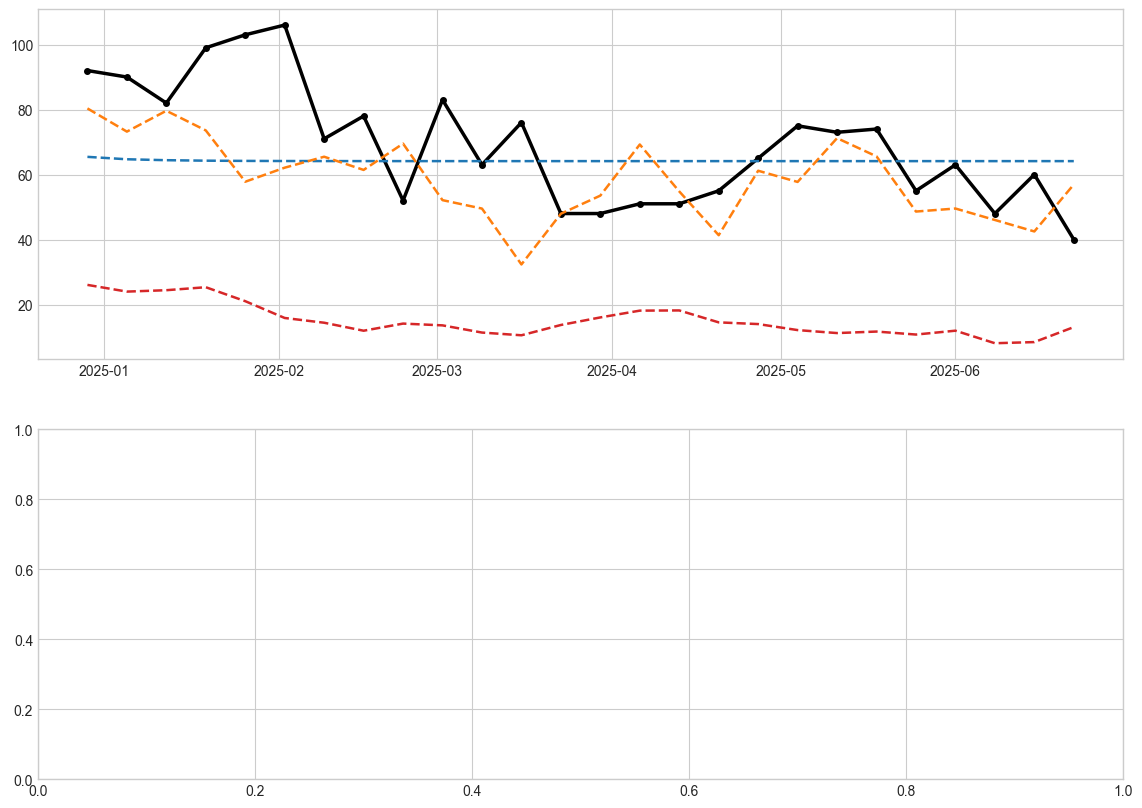

In [11]:
# ============================================================
# 9. GENERACIÓN DE GRÁFICOS PARA REVISIÓN DE PREDICCIONES
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configurar estilo visual limpio para tesis
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# ------------------------------------------------------------
# GRÁFICO 1: ZOOM AL PERIODO DE TESTEO (PRIMER SEMESTRE 2025)
# ------------------------------------------------------------
# Graficar la serie real del SIVIGILA en el Test
ax1.plot(y_test_real.index, y_test_real.values, label='Casos Reales (SIVIGILA)', 
         color='black', linewidth=2.5, linestyle='-', marker='o', markersize=4)

# Colores asignados para diferenciar las familias en el gráfico
colores_modelos = {'ARIMA': '#1f77b4', 'ARIMAX': '#ff7f0e', 'LASSO_Puro': '#d62728', 
                   'SARIMA': '#2ca02c', 'SARIMAX': '#9467bd'}

# Volver a correr un bucle rápido solo para extraer las predicciones óptimas y graficarlas
for modelo_nombre in mejores_por_familia['Modelo'].unique():
    # Extraer la configuración ganadora para esta familia
    config_ganadora = mejores_por_familia[mejores_por_familia['Modelo'] == modelo_nombre]['Configuración'].values[0]
    
    # Buscar el experimento correspondiente en la lista global de métricas filtrada
    fila_res = df_res[(df_res['Modelo'] == modelo_nombre) & (df_res['Configuración'] == config_ganadora)].iloc[0]
    
    # Re-generar o extraer la predicción de prueba para este modelo específico
    if modelo_nombre == 'LASSO_Puro':
        pred_te_graf = inversa_total_local(lasso_model.predict(X_test_scaled))
    else:
        # Re-ajustar brevemente el modelo ganador para obtener su vector de predicción exacto
        exp_opt = [e for e in experimentos if e['tipo'] == modelo_nombre][0]
        # Extraer los órdenes desde el string guardado
        if 'seasonal' in config_ganadora:
            # Reconstrucción de tuplas para estacionales
            ord_p = eval(config_ganadora.split('order=')[1].split(' ')[0])
            ord_s = eval(config_ganadora.split('seasonal=')[1])
        else:
            ord_p = eval(config_ganadora.split('order=')[1])
            ord_s = (0,0,0,0)
            
        model_graf = SARIMAX(endog=y_train, exog=exp_opt['exog_tr'], order=ord_p, seasonal_order=ord_s)
        fitted_graf = model_graf.fit(disp=False)
        pred_te_graf = np.expm1(fitted_graf.predict(start=y_test.index[0], end=y_test.index[-1], exog=exp_opt['exog_te']))
    
    # Graficar la curva del modelo
    ax1.plot(y_test_real.index, pred_te_graf, label=f'{modelo_nombre} ({config_ganadora})',
             color=colores_modelos.get(modelo_nombre, '#7f7f7f'), linewidth=1.8, linestyle='--')

ax1.set_title('A. Zoom de Validación Fuera de Muestra: Predicción vs Casos Reales (Primer Semestre 2025)', 
              fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Número de Casos de Dengue (Semanales)', fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.tick_params(axis='x', rotation=15)
ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------
# GRÁFICO 2: PANORÁMICA COMPLETA DE LA SERIE TEMPORAL (2021-2025)
# ------------------------------------------------------------
# Unir el histórico real completo
y_completa_real = pd.concat([y_train_real, y_test_real])
ax2.plot(y_completa_real.index, y_completa_real.values, label='Historial Real (SIVIGILA)', 
         color='black', linewidth=1.5, alpha=0.8)

# Sombrear el área que corresponde al entrenamiento y la que corresponde al testeo
ax2.axvspan(y_train_real.index[0], y_train_real.index[-1], color='gray', alpha=0.1, label='Periodo de Entrenamiento (2021-2024)')
ax2.axvspan(y_test_real.index[0], y_test_real.index[-1], color='yellow', alpha=0.08, label='Ventana de Evaluación SAT (1S-2025)')

# Graficar únicamente el mejor modelo global (ARIMAX o ARIMA según tu tabla) para no saturar visualmente
mejor_modelo_global = mejores_por_familia.loc[mejores_por_familia['MAE_Test'].idxmin()]['Modelo']
config_global = mejores_por_familia.loc[mejores_por_familia['MAE_Test'].idxmin()]['Configuración']

# Obtener ajuste del ganador para el pasado
exp_global = [e for e in experimentos if e['tipo'] == mejor_modelo_global][0]
ord_p = eval(config_global.split('order=')[1].split(' ')[0]) if 'seasonal' in config_global else eval(config_global.split('order=')[1])
ord_s = eval(config_global.split('seasonal=')[1]) if 'seasonal' in config_global else (0,0,0,0)

model_g = SARIMAX(endog=y_train, exog=exp_global['exog_tr'], order=ord_p, seasonal_order=ord_s)
fitted_g = model_g.fit(disp=False)
pred_tr_completa = np.expm1(fitted_g.fittedvalues)
pred_te_completa = np.expm1(fitted_g.predict(start=y_test.index[0], end=y_test.index[-1], exog=exp_global['exog_te']))

# Combinar predicciones del ganador
pred_ganador_total = pd.concat([pred_tr_completa, pred_te_completa])

ax2.plot(pred_ganador_total.index, Hayden_ganador_total := pred_ganador_total.values, 
         label=f'Predicción del Mejor Modelo: {mejor_modelo_global}', 
         color='#ff7f0e', linewidth=1.8, linestyle=':')

ax2.set_title(f'B. Perspectiva Histórica Completa del Sistema de Alerta Temprana (Ganador: {mejor_modelo_global})', 
              fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Línea Temporal (Semanas Epidemiológicas)', fontsize=11)
ax2.set_ylabel('Número de Casos de Dengue', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=9)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()